Updated model to modify for normalization N and baseline B.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [569]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs

config, _ = load_default_chrom_configs()

real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1)

Initializing N using config H.
Initializing B using timepoint 0


###### 

In [570]:
# real_deconv1.config.params_dic['mu0'] = -20.89
# real_deconv1.config.params_dic['delta'] = 0
# real_deconv1.config.params_dic['sigma0'] = 4.84
# real_deconv1.config.params_dic['lambda'] = 65
# real_deconv1.config.params_dic['gamma1'] = 0.0
# real_deconv1.config.params_dic['halted'] = 0.2

In [571]:
real_deconv1.config.update_timepoints()
real_deconv1.config.calculate_H()
real_deconv1.config.params_dic

{'mu0': -26.7901,
 'delta': 8.1805,
 'sigma0': 10.9885,
 'sigmav': 0.1424,
 'lambda': 68.1914,
 'gamma1': 0.0041,
 'gamma2': 0.2547,
 'halted': 0.2245,
 'alpha': 22}

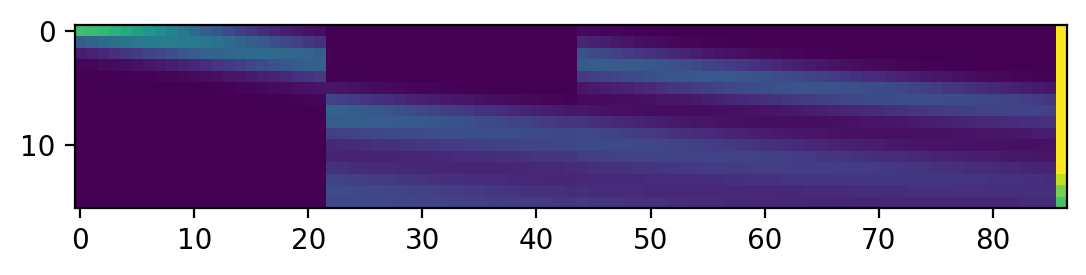

In [572]:
plt.imshow(real_deconv1.H, vmax=0.1)

In [573]:
real_deconv1.iterative_deconvolution_updates(5)

Iteration 0
0/368 - 00:00:00.002
100/368 - 00:00:00.096
200/368 - 00:00:00.172
300/368 - 00:00:00.251
0.006283419901301835
Iteration completed 00:00:00.346, rn=0.006283419901301833
Iteration 1
0/368 - 00:00:00.347
100/368 - 00:00:00.426
200/368 - 00:00:00.506
300/368 - 00:00:00.586
0.00442703733302984
Iteration completed 00:00:00.825, rn=0.00442703733302984
Iteration 2
0/368 - 00:00:00.826
100/368 - 00:00:00.906
200/368 - 00:00:00.986
300/368 - 00:00:01.066
0.004113152765615543
Iteration completed 00:00:01.145, rn=0.0041131527656155424
Iteration 3
0/368 - 00:00:01.146
100/368 - 00:00:01.226
200/368 - 00:00:01.307
300/368 - 00:00:01.404
0.003953469425160773
Iteration completed 00:00:01.513, rn=0.003953469425160774
Iteration 4
0/368 - 00:00:01.515
100/368 - 00:00:01.595
200/368 - 00:00:01.675
300/368 - 00:00:01.760
0.003885066912221466
Iteration completed 00:00:01.836, rn=0.0038850669122214667


In [574]:
# First run to get an initial estimation of F

In [575]:
from src.optimize_H import ParameterOptimizer

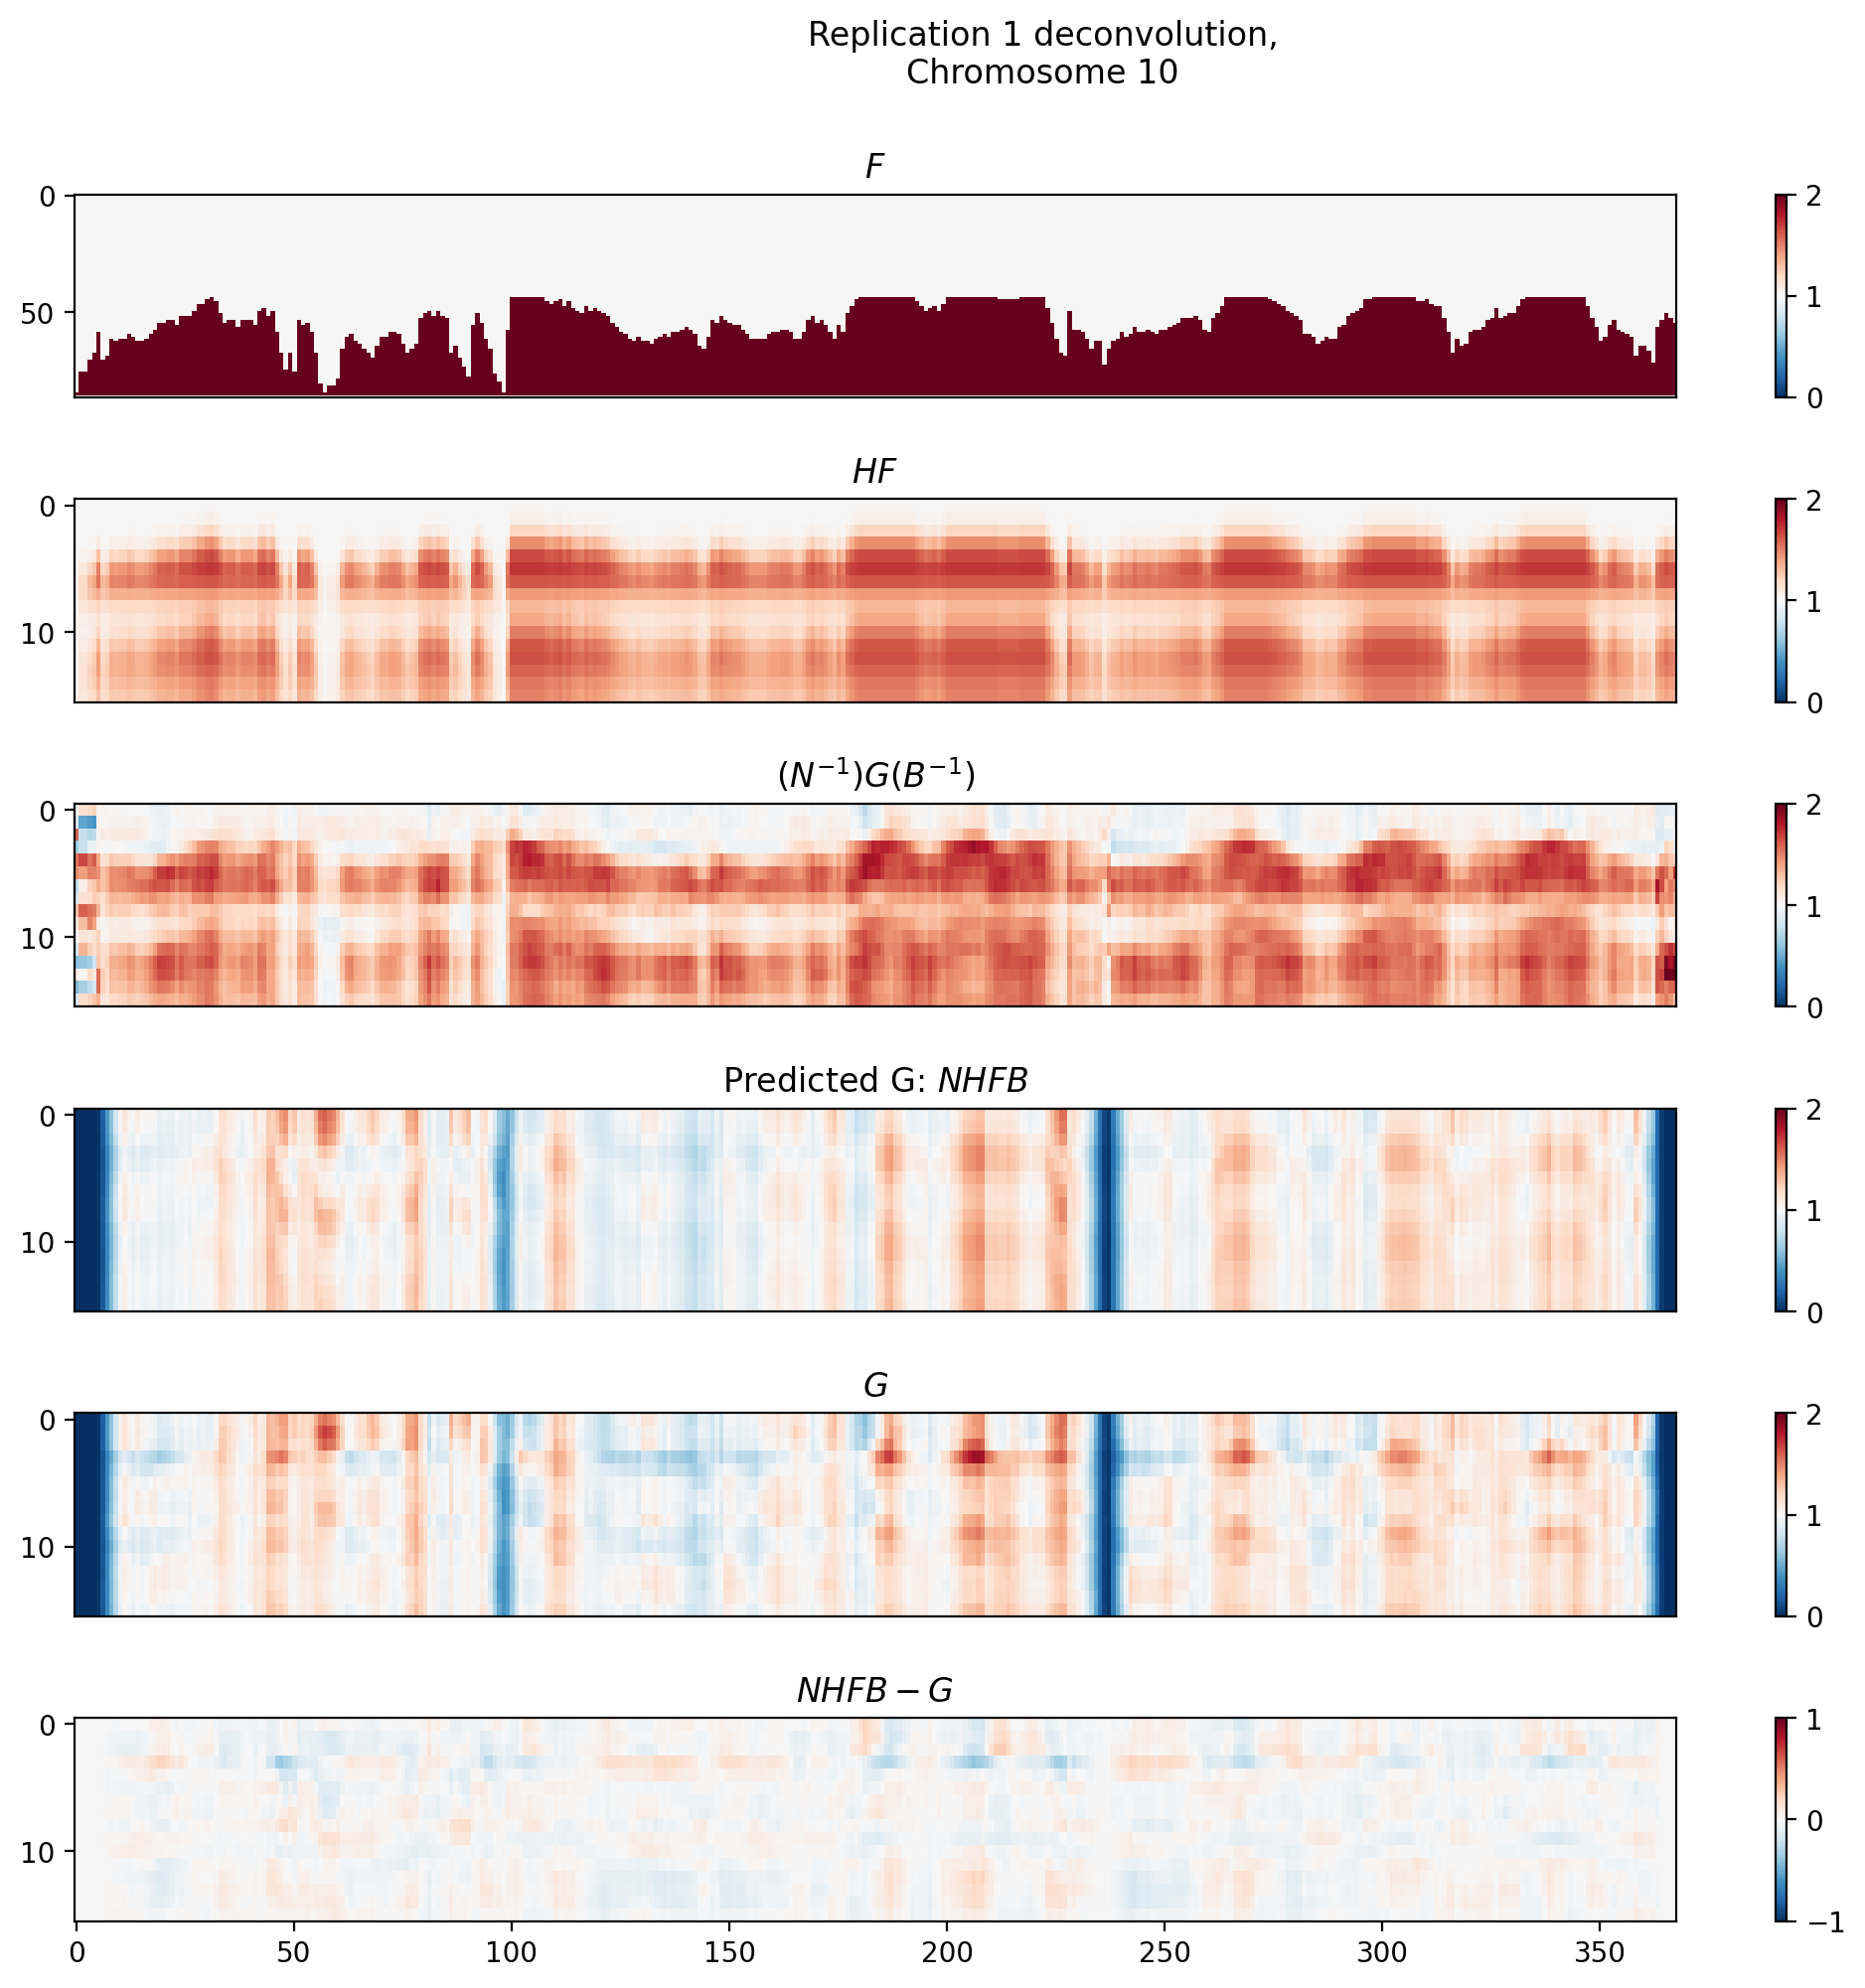

In [576]:
real_deconv1.plot_heatmaps()

In [577]:
config.params_dic

{'mu0': -26.7901,
 'delta': 8.1805,
 'sigma0': 10.9885,
 'sigmav': 0.1424,
 'lambda': 68.1914,
 'gamma1': 0.0041,
 'gamma2': 0.2547,
 'halted': 0.2245,
 'alpha': 22}

In [578]:
timepoints = config.timepoints
initial_values = {
    'mu0': -26.1348,
   'sigma0': 10.9885,
#    'delta': 8.63778,
#     'lambda': 68.003,
# #     'gamma1': 0.24,
#     'halted': 0.24,
}

init_params_df = pd.DataFrame(initial_values, index=['value']).T


In [579]:
bounds_dic = {
    'mu0': (-30, -10),
#     'lambda': (60, 80),
#     'delta': (1, 14),
    'sigma0': (1, 14),
#     'halted': (0.24, 0.24),
}

bounds_params_df = pd.DataFrame(bounds_dic, index=['min', 'max']).T
params_df = init_params_df.join(bounds_params_df)
params_df


,value,min,max
mu0,-26.1348,-30,-10
sigma0,10.9885,1,14


In [580]:
start, end = 0, 368

abbreviated_G = G[:, start:end]
abbreviated_F = F[:, start:end]
abbreviated_B = B[:, start:end][start:end, :]

In [581]:
real_deconv1.setup_deconvolution(real_deconv1.config)

Initializing N using config H.
Initializing B using timepoint 0


In [582]:
real_deconv1.iterative_deconvolution_updates(5)

Iteration 0
0/368 - 00:00:00.001
100/368 - 00:00:00.079
200/368 - 00:00:00.158
300/368 - 00:00:00.235
0.006283419901301835
Iteration completed 00:00:00.306, rn=0.006283419901301833
Iteration 1
0/368 - 00:00:00.307
100/368 - 00:00:00.387
200/368 - 00:00:00.466
300/368 - 00:00:00.545
0.00442703733302984
Iteration completed 00:00:00.622, rn=0.00442703733302984
Iteration 2
0/368 - 00:00:00.623
100/368 - 00:00:00.702
200/368 - 00:00:00.781
300/368 - 00:00:00.860
0.004113152765615543
Iteration completed 00:00:00.935, rn=0.0041131527656155424
Iteration 3
0/368 - 00:00:00.936
100/368 - 00:00:01.016
200/368 - 00:00:01.095
300/368 - 00:00:01.174
0.003953469425160773
Iteration completed 00:00:01.256, rn=0.003953469425160774
Iteration 4
0/368 - 00:00:01.257
100/368 - 00:00:01.336
200/368 - 00:00:01.415
300/368 - 00:00:01.495
0.003885066912221466
Iteration completed 00:00:01.573, rn=0.0038850669122214667


In [583]:
optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv1.N,
    F=real_deconv1.F,
    B=real_deconv1.B,
    G=real_deconv1.G
)


In [ ]:
from src.timer import Timer
from src.single_G1_config import calcH

timer = Timer()

num_epochs = 10
num_iterations_N_B = 5
update_params_df = pd.DataFrame()

#real_deconv1.setup_deconvolution(real_deconv1.config)
N = real_deconv1.N
B = real_deconv1.B

optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv1.N,
    F=real_deconv1.F,
    B=real_deconv1.B,
    G=real_deconv1.G
)

for epoch in range(num_epochs):
    print("Epoch: ", epoch)
    
    optimizer.optimize(maxiter=1000, verbose=True)

    real_deconv1.H = optimizer.current_H
        
    real_deconv1.iterative_deconvolution_updates(
        total_iterations=num_iterations_N_B, timer=timer,
        initial_B=B, initial_N=N)
    timer.print_time()
    
    params_row = pd.DataFrame([optimizer.params_df['value']], index=[epoch])
    params_row['opt_H_loss'] = optimizer.rn
    params_row['F_rn'] = real_deconv1.rn

    update_params_df = pd.concat([update_params_df, params_row])
    
    optimizer.N = real_deconv1.N
    optimizer.B = real_deconv1.B
    optimizer.F = real_deconv1.F
    
    N = real_deconv1.N
    B = real_deconv1.B

    print(update_params_df.iloc[-1])


Epoch:  0
Optimization [1]: Current loss: 0.0038538278769212476
Optimization terminated successfully.
         Current function value: 0.003850
         Iterations: 17
         Function evaluations: 34
Iteration 0
0/368 - 00:00:07.863
100/368 - 00:00:07.944
200/368 - 00:00:08.025
300/368 - 00:00:08.104
0.0038352854780618834
Iteration completed 00:00:08.176, rn=0.003835285478061883
Iteration 1
0/368 - 00:00:08.178
100/368 - 00:00:08.262
200/368 - 00:00:08.346
300/368 - 00:00:08.429
0.003799412026006239
Iteration completed 00:00:08.497, rn=0.0037994120260062382
Iteration 2
0/368 - 00:00:08.498
100/368 - 00:00:08.581
200/368 - 00:00:08.662
300/368 - 00:00:08.745
0.0037821946888814176
Iteration completed 00:00:08.822, rn=0.003782194688881417
Iteration 3
0/368 - 00:00:08.823
100/368 - 00:00:08.902
200/368 - 00:00:08.982
300/368 - 00:00:09.061
0.003776093449032511
Iteration completed 00:00:09.135, rn=0.003776093449032515
Iteration 4
0/368 - 00:00:09.136
100/368 - 00:00:09.215
200/368 - 00:00

In [ ]:
r, c = 2, 5

plt.figure(figsize=(16, 6))

for i, param in enumerate(update_params_df.columns):
        
    plt.subplot(r, c, i+1)
    plt.plot(update_params_df[param])
    plt.title(param)
    
plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.suptitle(f"Cell cycle parameter updates, {num_epochs} epochs")

In [ ]:
plt.imshow(config.H, vmax=0.05)

In [ ]:
real_deconv1.plot_heatmaps()

In [ ]:
plt.imshow(config.H, vmax=0.05)

In [ ]:
config.params_dic

In [ ]:
# This process appears very sensitive to the starting conditions.
# In this case, we seeded the model with a lower mu0 and sigma0 than CLOCCS
# and the optimizer stays around these values....
#
# An rn of rn=0.0032774171812892123 is achieved.
#

# I hypothesize that with a different mu0 and sigma0, the rn will converge to something
# slightly different and stay there.... Perhaps N and B have a greater influence
# on the convergence values....

# In a vacuum, we could either: (1) Not update N and B or (2) examine the differences in 
# convergence for a single epoch...
#


# Looks like it may have been a bug with the initialization of the N and B value
# 1. Run 5 iterations of the NBF updates, so we have a stable estimation 
# 2. Make sure N,B, and F are initialized properly for the updates of the optimizer
# 3. Ensure the config.H and deconv H are the same (updated properly.

)